<img src="https://raw.githubusercontent.com/chrisvdweth/selene/refs/heads/master/notebooks/images/logo/selene-logo-640.png" style="max-height:75px;" alt="SELENE Logo" />

**Disclaimer:** This Jupyter Notebook contains content generated with the assistance of AI. While every effort has been made to review and validate the outputs, users should independently verify critical information before relying on it. The SELENE notebook repository is constantly evolving. We recommend downloading or pulling the latest version of this notebook from Github.

# Linear Discriminant Analysis (LDA)

Linear Discriminant Analysis (LDA) is a classical machine learning technique that serves two closely related purposes: **dimensionality reduction** and **classification**. Originally developed in statistics, LDA seeks to transform high-dimensional data into a lower-dimensional representation while preserving information that is most useful for distinguishing between predefined classes. This makes LDA particularly valuable for visualization, feature extraction, and as a preprocessing step before applying other machine learning algorithms.

LDA is closely related to **Principal Component Analysis (PCA)** in that both methods aim to find a linear transformation that maps the original feature space into a lower-dimensional subspace. In both cases, the transformed features are linear combinations of the original variables, allowing us to represent the data with fewer dimensions while retaining important information. As a result, LDA and PCA are often discussed together as fundamental techniques for dimensionality reduction.

Despite this similarity, the two methods differ fundamentally in their optimization objectives. PCA is an **unsupervised** technique that identifies directions of maximum variance in the data, without considering any class labels. Its goal is to capture as much of the overall data variability as possible. In contrast, LDA is a **supervised** technique that explicitly uses class labels and seeks directions that maximize the separation between different classes while minimizing the spread of samples within the same class. Consequently, the resulting low-dimensional representation is often more suitable for classification tasks.

In this notebook, we will explore the mathematical foundations of LDA, understand how it constructs discriminative projection directions, and compare its behavior with PCA. We will then apply LDA to real datasets to demonstrate how it can simultaneously reduce dimensionality and improve class separability, making it a powerful tool for both data analysis and predictive modeling.

### Setting up the Notebook

#### Make Required Imports

This notebook requires the import of different Python packages but also additional Python modules that are part of the repository. If a package is missing, use your preferred package manager (e.g., [conda](https://anaconda.org/anaconda/conda) or [pip](https://pypi.org/project/pip/)) to install it. If the code cell below runs with any errors, all required packages and modules have successfully been imported.

In [1]:
from src.utils.libimports.lda import *
from src.utils.plotting.lda import *
from src.utils.data.files import *

#### Download Required Data

Some code examples in this notebook use data that first need to be downloaded by running the code cell below. If this code cell throws any error, please check the configuration file `config.yaml` if the URL for downloading datasets is up to date and matches the one on Github. If not, simply download or pull the latest version from Github.

In [2]:
demo_data_2d, _ = download_dataset("tabular/resources/lda-demo-data-2d.csv")
demo_data_3d, _ = download_dataset("tabular/resources/lda-demo-data-3d.csv")

File 'data/datasets/tabular/resources/lda-demo-data-2d.csv' already exists (use 'overwrite=True' to overwrite it).
File 'data/datasets/tabular/resources/lda-demo-data-3d.csv' already exists (use 'overwrite=True' to overwrite it).


#### Prepare Data

For all examples in this notebook, we consider two small demo datasets: a $2$-dimensional dataset containing $20$ data points, and a $3$-dimensional dataset containing $200$ data points. Both CSV files simply contain the coordinates of each data point. The code cell below, loads both dataset files into Pandas DataFrames and converts them into NumPy arrays.

In [3]:
df_2d = pd.read_csv(demo_data_2d)
df_3d = pd.read_csv(demo_data_3d)

X_2d, y_2d = df_2d.iloc[:, 0:-1].to_numpy(), df_2d.iloc[:, -1].to_numpy()
X_3d, y_3d = df_3d.iloc[:, 0:-1].to_numpy(), df_3d.iloc[:, -1].to_numpy()

print(f"Shape of 2D dataset: {X_2d.shape}")
print(f"Shape of 3D dataset: {X_3d.shape}")

Shape of 2D dataset: (300, 2)
Shape of 3D dataset: (300, 3)


The notebook contains several plots visualizing the data.

#### Preliminaries

* This notebook includes a Python implementation of LDA from scratch. The focus is on understanding the fundamental steps and not on performance and optimization. In practice, you should use mature LDA implementations provided by popular libraries such as [scitkit-learn](https://scikit-learn.org/).
* While not critical, we recommend some familiarity with Principal Component Analysis (PCA) and dimensionality reduction techniques in general to appreciate some of the design decisions behind LDA.

---

## Introduction

For the purposes of this notebook, we will primarily focus on LDA as a dimensionality reduction technique. However, it is important to recognize that LDA has a dual role in machine learning. In addition to finding a lower-dimensional representation that maximizes class separability, LDA can also be used directly as a classifier by modeling the class-conditional distributions and assigning new observations to the most likely class. These two perspectives are closely connected: the discriminative projections obtained through dimensionality reduction are precisely the directions that facilitate accurate classification. The mathematical foundations and intuition behind both roles will be developed in greater detail in the following sections.

### Dimensionality Reduction: LDA vs PCA

Although not necessarily, let's motivate the idea behind LDA by comparing it with another dimensionality reduction technique: Principal Component Analysis (PCA). Most fundamentally, both LDA and PCA are linear methods, meaning they both try to find the "best" linear mapping from the original (higher-dimensional) space to the target (lower-dimensional) space. Mathematically, assuming a data matrix $\mathbf{X}\in\mathbb{R}^{n\times d}$, where $n$ is the number of data points and $d$ is the number of features, LDA and PCA aim to find a transition matrix $\mathbf{W}\in\mathbb{R}^{d\times p}$ to map $\mathbf{X}$ to a new data matrix $\mathbf{P}\in\mathbb{R}^{n\times p}$, where $p$ is then number of new features in the projected space; naturally, we want $p < d$ or typically even $p \ll d$.

What determines the "best" mapping (i.e., the "best" transition matrix $\mathbf{W}$). To provide an intuition for LDA and PCA, consider the simple $2$-dimensional binary classification dataset in the left plot in the figure below. PCA determines $\mathbf{W}$ that maximizes the spread of the projected data points in the target space, independent from any class labels &mdash; PCA is unsupervised! The plot in the middle shows the result of PCA after reducing the dimensionality of the example dataset from $2$ down to $1$ dimensions. Notice that classes are now suddenly overlapping; again, PCA does not care about overlapping when trying to find the best mapping. In contrast, the plot on the right shows the result of LDA where the classes remain well separated because, compared to PCA, LDA is a supervised method taking class labels into account.

<img src="images/plots/dimreduction/dimreduction-lda-example.png" style="margin:auto;width:100%" alt="LDA - Basic Idea">

While PCA has single optimization objective (i.e., maximize the spread of the data points in the target space), LDA has two objectives:

* **Minimize** the spread of data points of the same class in the target space
* **Maximize** the spread (i.e., the separation) of classes in the target space

The challenge and the main part of this notebook will be to formalize and solve these two optimization objectives.

### Classification with LDA

As we will discuss later in more detail, LDA makes two important assumption with respect to the data distribution:

* The feature vectors for *each class* are generated from a multivariate Gaussian distribution
* All classes share the same covariance matrix

In simple terms, this means that the distributions of data points for each look "blob-like", and the distributions for all classes look more or less quite similar; as shown in the left plot of the figure above. If this assumption holds for the input data, and since LDA performs a linear transformation, this means that these two assumptions also hold for the distributions of the data points *after* the transformation. For example, the plot below shows the Gaussians reflecting the two class distributions of the result of LDA (right plot in the figure above); as a side note: the symmetry with respect to the origin is just an artifact of the example data.

<img src="images/plots/lda/lda-classification-gaussian-example.png" alt="LDA - Binary Classification Gaussian Example">

Notice how the plot illustrates the two assumptions. Firstly, the distributions are Gaussians (here just univariate since the mapping the data into the $1$-dimensional space), and secondly, both Gaussians have the same shape, meaning they have the same variance. The only difference between these two distributions is their individual class mean.

Under these assumptions, LDA can estimate the probability density of observing a feature vector given a particular class. Using Bayes' rule, these class-conditional densities are combined with the class prior probabilities to compute a posterior probability for each class. A new observation is then assigned to the class with the highest posterior probability. The shared covariance assumption plays a particularly important role in simplifying the classification rule. Because all classes are assumed to have the same covariance matrix &mdash; or just the variance in the $1$-dimensional case &mdash; the quadratic terms that arise from the Gaussian probability densities cancel when comparing classes. This results in a linear discriminant function and, consequently, linear decision boundaries between classes. In the previous plot, the black dashed line represents the resulting decision boundary between the two classes; again, the fact that the decision boundary foes through the origin is just an artifact of this simple example.

Like for the dimensionality reduction component of LDA, we will need to formalize how LDA implements classification tasks.

---

## The LDA Algorithm

### Basic Assumptions & Limitations

LDA makes a series of assumptions for the underlying data to ensure meaningful results. Data (strongly) violating these assumptions may cause LDA to perform poorly with respect to both the dimensionality reduction as well as the classification component of LDA. Regarding the latter, LDA is a generative classification method that models the class-conditional distributions $P(\mathbf{x}∣y)$ and uses Bayes' rule to classify observations. Its theoretical optimality relies on several assumptions, some essential and some practical.

#### Data Distribution

The arguably most fundamental assumption of LDA is that each class comes from a **unimodal multivariate normal (Gaussian) distribution**. This means that the $d$-dimensional data points of the $i$-th class come from normal distribution with some class mean vector $\boldsymbol{\mu}_{k}$ and some covariance matrix $\Sigma_{k}$. More formally:

$$\large
\mathbf{x}\ |\ y=k \ \sim \mathcal{N} \left(\boldsymbol{\mu}_{k}, \Sigma_{k}\right)
$$

where $\mathbf{x}$ represents a $p$-dimensional feature vector and $y=k$ reads as "conditional on belonging to class $k$", meaning that we are looking at the distribution within that particular class. In simple terms, this assumption means that each class is represented by a single Gaussian "blob", i.e., a single $p$-dimensional cluster with a roughly elliptical shape.

#### Homoscedasticity

LDA assumes that the covariance matrices for all $C$ classes are the same, i.e.:

$$\large
\Sigma^{(1)} = \Sigma^{(2)} = \dots \Sigma^{(C)} = \Sigma
$$

This means that, while different classes may have different means (i.e., $\boldsymbol{\mu}_{k} \neq \boldsymbol{\mu}_{l}$), the must have approximately the same covariance structure, meaning that the classes are assumed to have similar variances, similar correlation between features, and thus overall a similar shape and orientation. In other words, a very tight cluster and a very spread out cluster for two classes would violate this assumption of homoscedasticity.

Let's actually check, at least by eyeballing, if our two example datasets do not violate these two core assumptions, starting with the $2$-dimensional dataset; we provide the auxiliary methods `plot_data_2d()` for that. It is easy to see that this dataset fulfills the requirements: all clusters look like Gaussian blobs and all clusters have a similar spread. In fact, the dataset has been generated such that all classes come from a normal distribution with equal variance; even the number of data points for each class is the same (which is not required!).

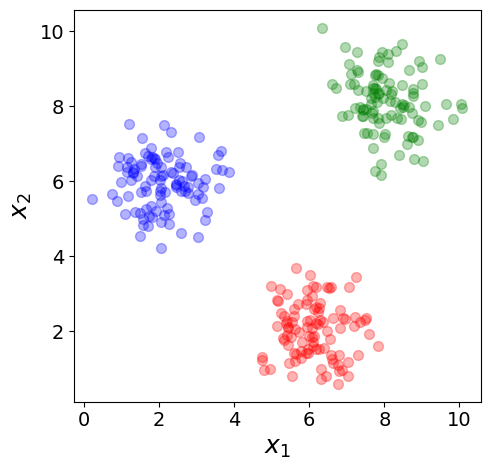

In [4]:
plot_data_2d(X_2d, y_2d)

Using the second auxiliary method `plot_data_3d()`, we can also visualize the $3$-dimensional dataset. Again, we see a Gaussian blob for each class, and all blobs show a similar spread. This dataset was also synthetically generated to represent an "ideal" example of a dataset of LDA.

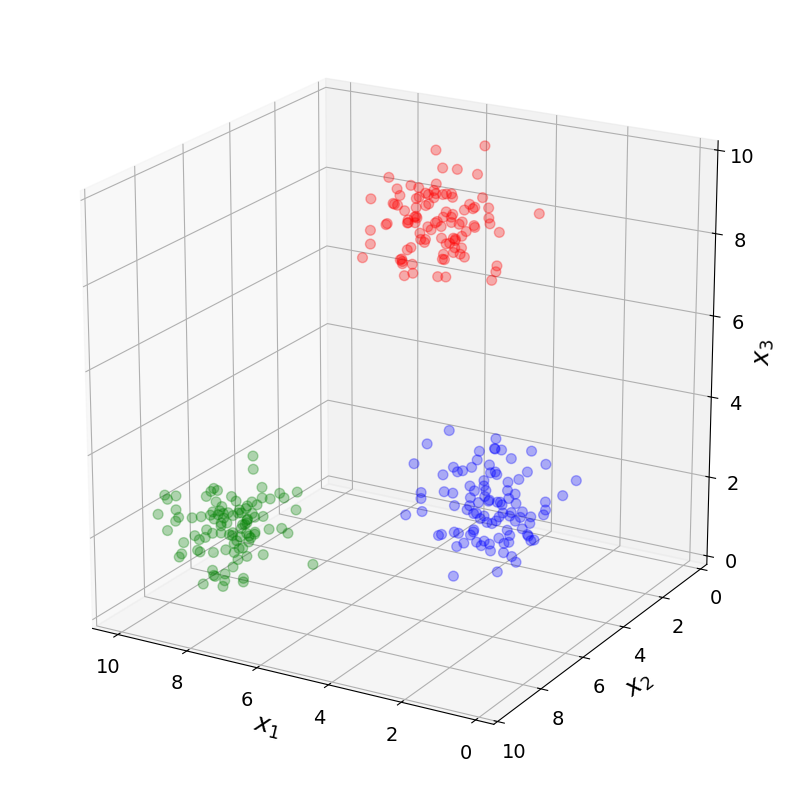

In [5]:
plot_data_3d(X_3d, y_3d, azim=120)

#### General assumptions

Apart from these two core assumptions, LDA makes several additional assumptions which are very common for a wide range of similar statistical models:

* The individual data points must be statistically independent of one another
* Sufficient number of data points to yield reliable estimates for all class means $\boldsymbol{\mu}_{k}$ and the covariance matrix $\Sigma$
* No excessive outlier that might overly distort the class means or inflate covariance estimates
* The covariance $\Sigma$ is non-singular so we can compute the inverse $\Sigma^{-1}$; this assumes that no features are perfectly collinear, there are more data points than features, and no features are linear combinations of each other.

At the end of the notebook, once we have covered and understood all the algorithms underlying LDA, we will discuss how violations to some of these assumptions will affect the effectiveness of LDA.

### Dimensionality Reduction

We already saw that LDA has two main objectives: minimizing the spread of points of the same class, and maximizing the spread between class means. To quantify the notion of how "spread" a set of points is, we typically compute the **variance or covariance**, which measures the average squared deviation from the mean. In LDA, however, it is more convenient to work with the **scatter matrix**, which is simply the unnormalized version of the covariance (and variance in the one-dimensional case). The scatter matrix omits the division by the number of points, but this normalization constant is irrelevant for LDA because the algorithm optimizes a ratio of between-class to within-class spread; as we will see in detail later.

**Important:** In the following, we first assume that we reduce the dimensionality of the original data into a $1$-dimensional space. In other words, the data matrix $\mathbf{W}$ will have a shape of $d\times 1$, which basically means that we are looking for the best transformation vector $\mathbf{w}$. This initial simplification helps to better understand the math. Afterwards, we can generalize the idea to mapping the original data into $p$-dimensional space (with $p>1$).

#### Within-Class Scatter

When measuring the spread of scalar values, the scatter (variance) can be computed by squaring the difference between each value and the mean. For vector-valued data, however, squaring a vector is not mathematically defined. Instead, we measure the magnitude of the deviation vector $(\mathbf{x}_i - \boldsymbol{\boldsymbol{\mu}})$ by taking its inner product with itself. This yields the squared Euclidean distance from the data point to the mean, $(\mathbf{x}_i - \boldsymbol{\boldsymbol{\mu}})^\top(\mathbf{x}_i - \boldsymbol{\boldsymbol{\mu}})$, which serves as the natural generalization of the squared deviation used in the scalar case.

In our context, for each individual class $k$ of size $n_k$, the data points are the projected $p$-dimenensional points $\mathbf{p}_{i}^{(k)}$, the mean is the class mean $\hat{\boldsymbol{\mu}}_{k}$ of the projected data points. With that we can compute the $J_W^{(k)}(\mathbf{w})$ for the $k$-th class as:

$$\large
J_W^{(k)}(\mathbf{w}) = \sum_{i=1}^{n^{(k)}} \left[\mathbf{p}_i^{(k)}-\hat{\boldsymbol{\mu}}_{k}\right]^\top\left[\mathbf{p}_i^{(k)}-\hat{\boldsymbol{\mu}}_{k}\right]
$$

Keep in mind that $J_W^{(k)}(\mathbf{w})$ is a scalar value quantifying the spread of the data points. Since both the projected data points $\mathbf{p}_{j}^{(k)}$ and projected class mean $\hat{\boldsymbol{\mu}}_{k}$ depend on the transformation vector $\mathbf{w}$, we can rewrite the expression to make this dependency explicit.

$$\large
J_W^{(k)}(\mathbf{w}) = \sum_{i=1}^{n^{(k)}} \left[\mathbf{w}^\top\mathbf{x}_i^{(k)}-\mathbf{w}^\top\boldsymbol{\mu}_{k}\right]^\top\left[\mathbf{w}^\top\mathbf{x}_i^{(k)}-\mathbf{w}^\top\boldsymbol{\mu}_{k}\right]
$$

In short, we now want to find the transformation vector $\mathbf{w}$ that minimizes $J_W^{(k)}(\mathbf{w})$. To get there, let's start simplifying the expression. Firstly, we can factor out the shared factor $\mathbf{w}^\top$ for both differences:

$$\large
J_W^{(k)}(\mathbf{w}) = \sum_{i=1}^{n^{(k)}} \left[\mathbf{w}^\top \left( \mathbf{x}_i^{(k)} - \boldsymbol{\mu}_{k}\right) \right]^\top \left[\mathbf{w}^\top \left( \mathbf{x}_i^{(k)} - \boldsymbol{\mu}_{k}\right) \right]
$$

For the first different term, we can now apply the rule. In other words, when taking the transpose of a product, the order of the factors is reversed and each factor is transposed. The general form of this rule is $(\mathbf{AB})^\top = \mathbf{B}^\top \mathbf{A}^\top$ where $\mathbf{A}$ and $\mathbf{B}$ can be matrices or vectors. Applied to our expression for $J_W^{(k)}(\mathbf{w})$, we get:

$$\large
J_W^{(k)}(\mathbf{w}) = \sum_{i=1}^{n^{(k)}} \left( \mathbf{x}_i^{(k)} - \boldsymbol{\mu}_{k}\right)^\top \mathbf{w} \mathbf{w}^\top \left( \mathbf{x}_j^{(k)} - \boldsymbol{\mu}_{k}\right)
$$

Recall that $J_W^{(k)}(\mathbf{w})$, which means that each term of the sum is also scalar value. We can also see this because both $\left( \mathbf{x}_i - \boldsymbol{\mu}_{k}\right)^\top$ and $\mathbf{w}^\top$ are row vectors (shape: $1\times d$) while $\left( \mathbf{x}_i - \boldsymbol{\mu}_{k}\right)$ and $\mathbf{w}$ are colum vectors (shape $d\times 1$). Notice that $\mathbf{w}$ (and $\mathbf{w}^\top$) do not depend on the value if $j$ and are therefore the same for each term in the sum. So what we want is to pull $\mathbf{w}$ and $\mathbf{w}^\top$ out of the sum. Ignoring the nitty-gritty details, the rules of linear algrebra allow us to rewrite our expression as:

$$\large
J_W^{(k)}(\mathbf{w}) =  \mathbf{w}^\top \left[ \sum_{i=1}^{n^{(k)}} \left(\mathbf{x}_i-\boldsymbol{\mu}_{k}\right)\left(\mathbf{x}_i-\boldsymbol{\mu}_{k}\right)^\top \right] \mathbf{w}
$$

Notice that each term of the sum is now the **outer product** outer product of difference vector with itself for a single data point. Since the difference vector is of size $d$, the outer product is a matrix of shape $d\times d$. Furthermore, since it is the out product with itself, the result matrix is always symmetric and positive semidefinite &mdash; we will see later what this means and why this means; right not, just take a note of this fact. Lastly, since each term of the sum yields a symmetric and positive semidefinite matrix, to sum itself will be a symmetric and positive semidefinite matrix. If we denote this matrix as $\mathbf{S}_W^{(k)}$, we get:

$$\large
J_W^{(k)}(\mathbf{w}) = \mathbf{w}^\top \mathbf{S}_W^{(k)} \mathbf{w}
$$

So far, we only considered a single class. In practice, of course, we want to minimize the within-class scatter with respect to each class. Since the quantity $J_W^{(k)}(\mathbf{w})$ we want to minimize is just a scalar value, we can simply sum up the all $J_W^{(k)}(\mathbf{w})$ for $1 \leq i \leq C$ and minimize that sum. If we denote this sum as $\large J_W(\mathbf{w})$, we get:

$$
\begin{align}
\large J_W(\mathbf{w})\ &\large = \sum_{k=1}^{C} \sum_{i=1}^{n^{(k)}} \left[\mathbf{p}_i^{(k)}-\hat{\boldsymbol{\mu}}_{k}\right]^\top\left[\mathbf{p}_i^{(k)}-\hat{\boldsymbol{\mu}}_{k}\right]\\[0.5em]
&\large = \sum_{k=1}^{C} J_W^{(k)}(\mathbf{w})\\[0.5em]
&\large = \sum_{k=1}^{C} \mathbf{w}^\top \mathbf{S}_W^{(k)} \mathbf{w}\\[0.5em]
\end{align}
$$

Since the within-class scatter matric $\mathbf{w}^\top \mathbf{S}_W^{(k)}$ for each class has the same shape and format, we can again move $\mathbf{w}^\top$ and $\mathbf{w}$ outside of the some and sum up all per-class with scatter matrices to a single within-class scatter matrix $\mathbf{S}_W$.

$$
\begin{align}
\large J_W(\mathbf{w})\ &\large = \mathbf{w}^\top \left(\sum_{k=1}^{C} \mathbf{S}_W^{(k)}\right) \mathbf{w}\\[0.5em]
&\large = \mathbf{w}^\top \mathbf{S}_W \mathbf{w}\\[0.5em]
\end{align}
$$

with $ \mathbf{S}_W = \sum_{k=1}^{C} \mathbf{S}_W^{(k)}$.

If you look at the expression above, the computation of $\mathbf{S}_W$ depends solely on the original dataset. The method `compute_Sw()` in the code cell below shows a practical implementation for computing $\mathbf{S}_W$. Note how the method computes the individual $\mathbf{S}_W^{(k)}$ for all classes and sums them up during the loop to yield the final scatter matrix $\mathbf{S}_W$.

In [6]:
def compute_Sw(X, y):
    C  = np.unique(y)      # C = set of class labels
    d  = X.shape[1]        # d = number of features
    Sw = np.zeros((d, d))  # Initialize S_w matrix
    # Compute and sum up all per-class scatter matrices
    for k in C:
        # Get all points labeled c
        Xk = X[y==k]              
        # Mean-center the data
        Xk -= np.mean(Xk, 0)
        # Add scatter matrix of X_c
        Sw += np.dot(Xk.T, Xk)  
    # Return final scatter matrix
    return Sw

We can apply the method `compute_Sw()` to compute the within-class scatter matrices for our two example datasets. The code below only prints the shapes of the two matrices as the actual values are not that interpretable. Here, it is just to show what we already know &mdash; that is, the within-class scatter matrix has the shape of $d\times d$, with $d$ being the original number of features.

In [7]:
Sw_2d = compute_Sw(X_2d, y_2d)
Sw_3d = compute_Sw(X_3d, y_3d)

print(f"Shape of Sw_2d: {Sw_2d.shape}")
print(f"Shape of Sw_3d: {Sw_3d.shape}")

Shape of Sw_2d: (2, 2)
Shape of Sw_3d: (3, 3)


Now that we can compute $\mathbf{S}_W$, we could try to find a vector $\mathbf{w}$ that minimizes $J_W(\mathbf{w})$. However, minimizing the within-class scatter is just one of the two optimization objectives of LDA. We still need to formalize the notion of maximizing the separation between classes (i.e., the between class scatter). So let's check that one out next.

#### Between-Class Scatter

In simple terms, the between-class scatter aims to measure &mdash; and then maximize &mdash; the separation between all classes. Treating each class as the set of all its data points would make measuring the separation mathematically quite cumbersome. Instead, LDA relies on the core assumption that each class comes from unimodal normal distribution. As such, to measure separation, LDA uses the class projected means $\hat{\boldsymbol{\mu}}_{k}$ to represent the $i$-th classes to compute the scatter of all $C$ class means. In other words, the class means are now the data points and the overall projected mean $\hat{\boldsymbol{\mu}}$ (i.e., the mean of all data points across all classes) is the mean of the class means.

We can visualize this by plotting our dataset with both the overall mean and all class means. Firstly, the plot below shows the data for our $2$-dimensional dataset. The large black $+$ markers in the middle of the class cluster reflect the respective class means. The large purple $\times$ marker represents the overall mean across all data points and clusters. Keep in mind, however, that LDA considers the overall mean and all class means *after* the transformation.

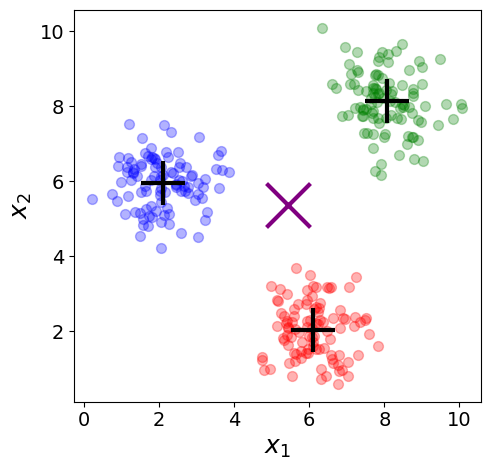

In [8]:
plot_data_2d(X_2d, y_2d, show_means=True)

We can do the same visualization for our $3$-dimensional example data; see the plot below. Of course, the concepts of the overall mean and all class means remain exactly the same.

In [9]:
plot_data_3d(X_3d, y_3d, show_means=True, azim=None)

Like for the within-class scatter, let's first consider the between-class scatter with respect to the $i$-th class. Thus, for class $i$, the displacement of its mean from the overall mean is $(\hat{\boldsymbol{\mu}}{(k)} - \hat{\boldsymbol{\mu}})$. Since LDA does *not* assume that all classes are of similar sizes in terms of the number of data points, we need to weigh each class by its size $n_{k}$. The argument is, for example, that a mean based on 100 data points is a more reliable indicator of group separation than a mean based on only 10 data points. And lastly, we want to consider the scatter across a classes, giving us the following expression for the between-class scatter $J_B^(\mathbf{w})$:

$$\large
J_B(\mathbf{w}) = \sum_{k=1}^{C} n_{k} \left[\hat{\boldsymbol{\mu}}_{k} - \hat{\boldsymbol{\mu}} \right]^\top\left[\hat{\boldsymbol{\mu}}_{k} - \hat{\boldsymbol{\mu}}\right]
$$

The steps we need to perform are also very similar to the ones for the within-class scatter. First, we replace the projected class mean the the project (overall) mean with the actual projection, i.e., the dot product between the transposed transformation vector $\mathbf{w}$ and the class mean $\boldsymbol{\mu}_{k}$ and overall mean $\boldsymbol{\mu}$.

$$\large
J_B(\mathbf{w}) = \sum_{k=1}^{C} n_{k} \left[\mathbf{w}^\top\boldsymbol{\mu}_{k} - \mathbf{w}^\top\boldsymbol{\mu} \right]^\top\left[\mathbf{w}^\top\boldsymbol{\mu}_{k} - \mathbf{w}^\top\boldsymbol{\mu}\right]
$$

We then factor out the shared factor $\mathbf{w}^\top$:

$$\large
J_B(\mathbf{w}) = \sum_{k=1}^{C} n_{k} \left[\mathbf{w}^\top \left( \boldsymbol{\mu}_{k} - \boldsymbol{\mu} \right) \right]^\top\left[\mathbf{w}^\top \left( \boldsymbol{\mu}_{k} - \boldsymbol{\mu} \right) \right]
$$

By applying the algebraic rule $(\mathbf{AB})^\top = \mathbf{B}^\top \mathbf{A}^\top$ where $\mathbf{A}$ and $\mathbf{B}$ again, we get:

$$\large
J_B(\mathbf{w}) = \sum_{k=1}^{C} n_{k} \left( \boldsymbol{\mu}_{k} - \boldsymbol{\mu} \right)^\top \mathbf{w} \mathbf{w}^\top \left( \boldsymbol{\mu}_{k} - \boldsymbol{\mu} \right) 
$$

Since $\mathbf{w}$ and $\mathbf{w}^\top$ do not depend on $i$, we can pull them out of the sum. We only need to take care to adjust the terms in the sum such that the overall expression remains equivalent.

$$\large
J_B(\mathbf{w}) = \mathbf{w}^\top \left[ \sum_{k=1}^{C} n_{k} \left( \boldsymbol{\mu}_{k} - \boldsymbol{\mu} \right) \left( \boldsymbol{\mu}_{k} - \boldsymbol{\mu} \right)^\top \right] \mathbf{w}
$$

Like before, ignoring the scalar value $n^{(k)}$ for a moment, each sum term is the outer product of the difference vector between the class mean and overall mean with itself. This outer product gives us the between-class scatter matrix $\mathbf{S}_B^{(k)}\in \mathbb{R}^{d\times d}$ for the $i$-th class. We can therefore rewrite our expression for $J_B(\mathbf{w})$ as follows:

$$
\begin{align}
\large J_B(\mathbf{w})\ &\large = \mathbf{w}^\top \left(\sum_{k=1}^{C} n^{(k)} \mathbf{S}_B^{(k)}\right) \mathbf{w}\\[0.5em]
&\large = \mathbf{w}^\top \mathbf{S}_B \mathbf{w}\\[0.5em]
\end{align}
$$

with $\mathbf{S}_B = \sum_{k=1}^{C} n^{(k)} \mathbf{S}_B^{(k)}$. Once again, since we compute the outer product between the difference vector with itself, all $\mathbf{S}_B^{(k)}$ and the resulting $\mathbf{S}_B$ are positive semidefinite matrices.

Based on the expression for $\mathbf{S}_B^{(k)}$ and $\mathbf{S}_B$, which only depend on the original data, we can also implement the computation of $\mathbf{S}_B$ as a Python method and using NumPy for convenience; the method `compute_Sb()` in the code cell below.

In [10]:
def compute_Sb(X, y):
    C  = np.unique(y)        # C = set of class labels
    d  = X.shape[1]          # d = number of features
    Sb = np.zeros((d, d))    # Initialize Sb matrix
    mu = np.mean(X, axis=0)  # Calculate overall mean
    # Compute and sum all per-class scatter matrices
    for k in C:
        # n_i number or points labeled c
        n_k = X[y==k,:].shape[0]
        # mu_i mean of points labeled c
        mu_k = np.mean(X[y==k], axis=0)
        # Calculate difference vector (= mean-centering class means)
        diff = (mu_k - mu).reshape(-1, 1)
        # Add scatter of difference vector
        Sb += n_k * np.dot(diff, diff.T)
    # Return final scatter matrix    
    return Sb

Although we already know that the between-class scatter matrix $\mathbf{S}_B$ has a shape of $d\times d$, let's still apply the method `compute_Sb()` to our two example datasets to confirm this.

In [11]:
Sb_2d = compute_Sb(X_2d, y_2d)
Sb_3d = compute_Sb(X_3d, y_3d)

print(f"Shape of Sb_2d: {Sb_2d.shape}")
print(f"Shape of Sb_3d: {Sb_3d.shape}")

Shape of Sb_2d: (2, 2)
Shape of Sb_3d: (3, 3)


Again, you are welcome to print the actual matrices, but like before the actual values are not easy to interpret.

#### Combining both Objectives

Recall that the central idea of LDA is to find a projection in which data points from different classes are as well separated as possible while points belonging to the same class remain tightly clustered. To achieve this, LDA maximizes the ratio of the between-class scatter $J_B(\mathbf{w})$ to the within-class scatter $J_W(\mathbf{w})$. Thus we define the final objective function $J(\mathbf{w})$ of LDA as:

$$\large
J(\mathbf{w}) = \frac{J_B(\mathbf{w})}{J_W(\mathbf{w})} = \frac{\mathbf{w}^\top \mathbf{S}_B \mathbf{w}}{\mathbf{w}^\top \mathbf{S}_W \mathbf{w}}
$$

The numerator measures how far apart the class means are, encouraging class separation, while the denominator measures how dispersed the data points are around their respective class means, penalizing overlap between classes. Maximizing this ratio therefore balances these two objectives simultaneously: it favors directions along which the class centers are far apart and the classes themselves are compact. As a result, the projected data becomes more discriminative, making it easier to distinguish between classes.

To find the solution that maximizes $J(\mathbf{w})$, we first have to remember that both scatter matrices $\mathbf{S}_B$ and $\mathbf{S}_W$ are **symmetric** and **positive semidefinite** matrices. A symmetric matrix $\mathbf{M}$ is positive semidefinite if, for any nonzero vector $\mathbf{x}$, it satisfy the condition $\mathbf{x}^\top\mathbf{Mx} \geq 0$. In fact, based on our initial assumptions &mdash;no features are perfectly collinear, there are more data points than features, and no features are linear combination of each other &mdash; $\mathbf{S}_W$ is **positive definite** (i.e., $\mathbf{w}^\top \mathbf{S}_W \mathbf{w} > 0$ for any nonzero vector $\mathbf{w}$).

Why is this important? With these conditions satisfied, the expression $\large \frac{\mathbf{w}^\top \mathbf{S}_B \mathbf{w}}{\mathbf{w}^\top \mathbf{S}_W \mathbf{w}}$ matches the [**Generalized Rayleigh Quotient**](https://en.wikipedia.org/wiki/Rayleigh_quotient). Skipping the mathematical details here, the vector $\mathbf{w}$ that maximizes this Generalized Rayleigh Quotient is the eigenvector associated with the largest eigenvalue of the matrix $\mathbf{S}_W^{-1}\mathbf{S_B}$, where $\mathbf{S}_W^{-1}$ is the inverse of the within-class scatter matric $\mathbf{S}_W$.

However, a single vector $\mathbf{w}$ can only project the data down to a $1$-dimensional line. If we have $C$ classes in an $n$-dimensional space, a $1$-dimensional line is rarely enough to capture all the structural differences between classes &mdash; and we will quantify this later. To project data onto a lower-dimensional subspace (of dimension $p > 1$), we need a projection matrix $\mathbf{W} = [\mathbf{w}_1, \mathbf{w}_2, \mathbf{w}_3, \dots, \mathbf{w}_p]$ rather than a single vector. Right now, given this formulation, we only found $\mathbf{w}_1$. However, again omitting the mathematical details here, it can be shown that $\mathbf{w}_2$, $\mathbf{w}_3$, ..., $\mathbf{w}_p$ are the eigenvectors associated with 2nd-largest, 3rd-largest, ..., $p$-largest eigenvalues of the matrix $\mathbf{S}_W^{-1}\mathbf{S_B}$. This means that performing LDA comes down to finding the $p$ eigenvectors with the largest eigenvalues of that matrix.

The method `lda()` provides a NumPy only implementation of LDA. The method naturally uses the existing methods `compute_Sw()` and `compute_Sb()` to compute the within-class scatter matrix $\mathbf{S}_B$ and between-class scatter matrix $\mathbf{S}_B$. For the heavy lifting &mdash; for computing the inverse $\mathbf{S}_W^{-1}$, as well as the eigenvectors and eigenvalues of $\mathbf{S}_W^{-1}\mathbf{S_B}$ &mdash; the implementation uses the NumPy methods [`np.linalg.inv()`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html) and [`np.linalg.eig()`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html). It then finds the top-$p$ eigenvalues (reflected by the input argument `n_components`) to form the transformation matrix `W` using the respective eigenvectors. The method returns the project $\mathbf{P} = \mathbf{XW}$.

In [12]:
def lda(X, y, n_components=1):
    # Calculate scatter matrices
    Sw = compute_Sw(X, y)
    Sb = compute_Sb(X, y)
    # Calculate all eigenvectors and eigenvalues
    eigenval, eigenvec = np.linalg.eig(np.linalg.inv(Sw).dot(Sb))
    # Find the the num_pc largest eigenvalues
    top_idx = np.argsort(eigenval)[::-1][:n_components]
    # Create transformation matrix W using eigenvectors with the largest eigenvalues
    W = eigenvec[:, top_idx]
    # Return the transformed data
    return X @ W, W

Thus we can now perform LDA to reduce the dimensionality of our example datasets using our own implementation. In the code cell below, we first map the $2$-dimensional dataset into a $1$-dimensional space, which is obviously the only option here. We also plot the shape of the projected data to confirm that output is indeed now a dataset with a single feature.

In [13]:
X_2d_lda, _ = lda(X_2d, y_2d, n_components=1)

print(f"{X_2d_lda.shape}")

(300, 1)


To better assess the result, we can also plot the projected data. However, the auxiliary method `plot_data_2d()` expects $2$-dimensional data. In the code cell below, we therefore first create a $2$-dimensional dataset by adding a second feature but where the value for all data points is zero. Again, we do this only to generate a nice plot!

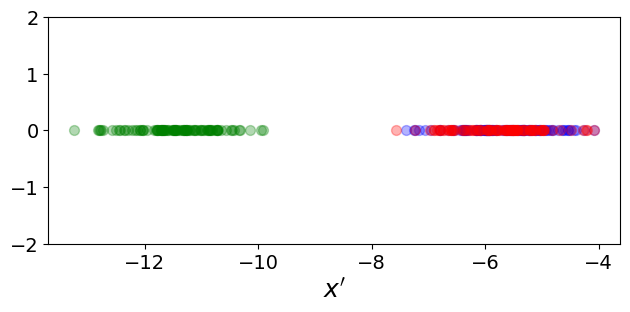

In [14]:
X_2d_lda_plot = np.column_stack((X_2d_lda, [0]*X_2d.shape[0]))

plot_data_2d(X_2d_lda_plot, y_2d, ylim=2, x_label="$x^\prime$", y_label="")

As the plot shows, the green class cluster remains well separated. However, the red and blue clusters are now very much overlapping, which means quite a loss of information that happened as part of the dimensionality reduction. This can occur because LDA performs a **linear transformation** that projects all data points onto a small number of discriminant axes. During this projection, information contained in directions that are not selected by LDA is discarded. Consequently, points that were separated along those discarded directions may be mapped closer together, causing previously distinct class clusters to overlap.

This behavior is a natural consequence of dimensionality reduction. LDA seeks projection directions that maximize the ratio of between-class variance to within-class variance, but it is constrained to move points only through a linear projection. Since all points are transformed according to the same linear mapping, LDA cannot independently preserve every separation that exists in the original space. Therefore, even when classes are perfectly or nearly perfectly separated in higher dimensions, the lower-dimensional representation may sacrifice some of that separation in order to retain the most discriminative structure overall.

Just as a sanity check, to see if our own implementation of LDA is indeed correct, we can also perform the same reduction using the [`LinearDiscriminantAnalysis`](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html) implementation provided by [scitkit-learn](https://scikit-learn.org/).

In [15]:
sklearn_lda = LinearDiscriminantAnalysis(n_components=1)

X_2d_sklearn_lda = sklearn_lda.fit_transform(X_2d, y_2d)

If we now plot the projected dataset, we see that it matches the result using our own implementation.

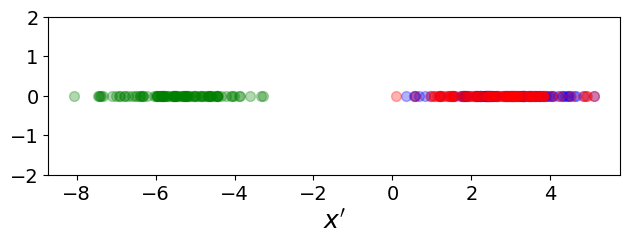

In [16]:
X_2d_sklearn_lda_plot = np.column_stack((X_2d_sklearn_lda, [0]*X_2d.shape[0]))

plot_data_2d(X_2d_sklearn_lda_plot, y_2d, ylim=2, x_label="$x^\prime$", y_label="")

We can now consider our $3$-dimensional example dataset. Here, we have two options: reducing it to $2$ dimensions or $1$ dimensions. Let's first apply our LDA implementation to reduce the $3$-dimensional dataset down to $2$ dimensions; again, the code cell below also prints the shape of the project data to confirm its reduced dimensionality.

In [17]:
X_3d_lda2, _ = lda(X_3d, y_3d, n_components=2)

print(f"{X_3d_lda2.shape}")

(300, 2)


Since we now have a $2$-dimensional dataset, we can directly use the auxiliary method `plot_data_2d()` to visualize the result.

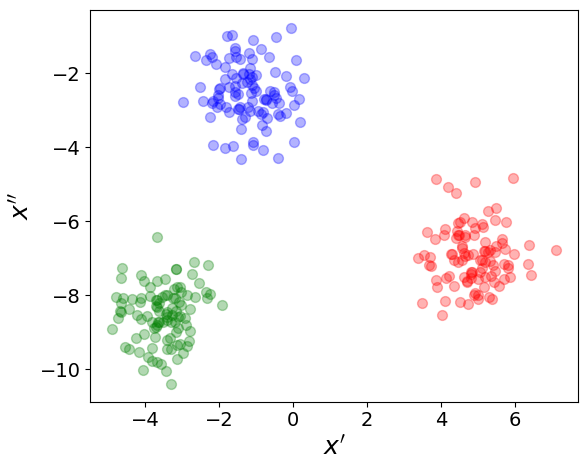

In [18]:
plot_data_2d(X_3d_lda2, y_3d, x_label="$x^\prime$", y_label="$x^{\prime\prime}$")

Keep in mind that this is *not* a plot of the $2$-dimensional dataset but of the reduced $3$-dimensional dataset. Here, we can see that the reduction of the dataset from $3$ down to $2$ dimensions did not incur any critical loss of information: all three class clusters are still well separated. Now let's see what happens if we use LDA to reduce the number of dimensions from $3$ down to $1; we only need to change the input argument to `n_components=1`.

In [19]:
X_3d_lda1, _ = lda(X_3d, y_3d, n_components=1)

print(f"{X_3d_lda1.shape}")

(300, 1)


To plot the result, we once again need to add an artificial feature with all zero values.

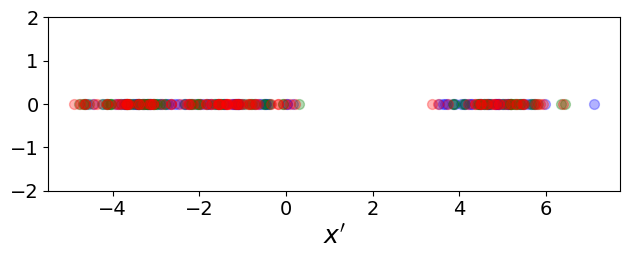

In [20]:
X_3d_lda1_plot = np.column_stack((X_3d_lda1, [0]*X_2d.shape[0]))

plot_data_2d(X_3d_lda1_plot, y_2d, ylim=2, x_label="$x^\prime$", y_label="")

Notice how the results show that data points from all classes wildly overlap. It is easy to see that reduction of the $3$-dimensional dataset down to just $1$-dimensional incurred too much information loss. In fact, the result looks worse than the reduction of the $2$-dimensional dataset down to $1$ dimension &mdash; see above, where at least the green class remained well separated.

This might not seem very intuitive since the reduction of the $3$-dimensional dataset to $2$ dimensions looks very similar to the original $2$-dimensional dataset. However, we can confirm the result by taking the reduced dataset (from $3$ to $2$ dimensions) and apply LDA again to further reduce it down to $1$ dimension; which, together with plotting the result, is done by the code cell below.

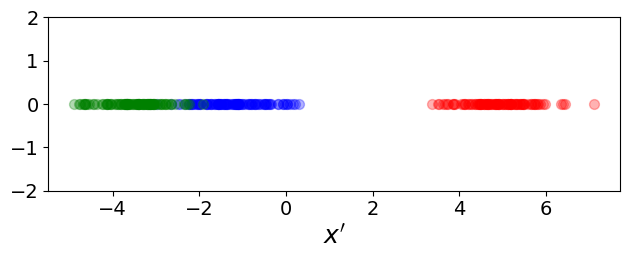

In [21]:
X_3d_lda1, _ = lda(X_3d_lda2, y_3d, n_components=1)

X_3d_lda1_plot = np.column_stack((X_3d_lda1, [0]*X_3d.shape[0]))

plot_data_2d(X_3d_lda1_plot, y_3d, ylim=2, x_label="$x^\prime$", y_label="")

Appreciate how the last two plots are identical. When using LDA, reducing the dimensionality in several successive steps yields the same result as reducing it directly to the target dimension in a single step, provided the same discriminant subspace is retained. This property follows from the fact that LDA is a linear transformation: the composition of multiple linear transformations is itself a linear transformation. Therefore, projecting data first from a high-dimensional space to an intermediate space and then to a lower-dimensional space is mathematically equivalent to applying a single projection matrix that maps directly to the final space. As a result, the order or number of intermediate reduction steps does not fundamentally alter the resulting discriminant subspace, unlike some nonlinear dimensionality reduction techniques where the transformation path can affect the outcome.

### Classification

Recall that LDA can not only be used for dimensionality reduction but also as a classification model. LDA is fundamentally a generative, probabilistic classifier that leverages Bayes' Theorem to predict the class of a given data point. Instead of directly modeling the decision boundary between classes, LDA models the distribution of the predictor variables ($\mathbf{x}$) within each target class ($y_k$), with $1 \leq k \leq C$. It assumes that the continuous predictors follow a multivariate normal distribution and that all classes share a common covariance matrix. By combining these class-conditional probabilities &mdash; often referred to as the likelihood &mdash; with the prior probabilities of each class, LDA uses Bayes' Theorem to calculate the posterior probability, $P(y_k | \mathbf{x})$, which represents the likelihood that the observation belongs to a specific class $k$ given its observed feature values:

$$\large
P(y_k | \mathbf{x}) = \frac{P(\mathbf{x}\mid y_k)P(y_k)}{P(\mathbf{x})}
$$

To make a prediction, LDA computes the posterior probability $P(y_k | \mathbf{x})$ for each class $k$ and returns to class with the highest probability; more formally:

$$
\begin{align}
\large \hat{y}\ &\large = \arg\max_k P(y_k \mid \mathbf{x})\\[0.5em]
&\large = \arg\max_k \frac{P(\mathbf{x}\mid y_k)P(y_k)}{P(\mathbf{x})}
\end{align}
$$


So, how do we compute these posterior probabilities. The first thing we can do is to simplify the expression by dropping the denominator, i.e., the marginal probability $P(\mathbf{x})$. Since the denominator does not depend on the class, it can be considered a constant. When making predictions, we are actually not interested in the true posterior probabilities but only in their relative differences for each class to find the class with the highest probabilities. In other words, for the prediction task, it is sufficient to know that the posterior probability $P(y_k | \mathbf{x})$ is proportional to the numerator of the original expression:

$$\large
P(y_k \mid \mathbf{x}) \propto P(\mathbf{x} \mid y_k)P(y_k)
$$

Another simplification step, which will become clearer a bit later, is not to compute probabilities but log probabilities. Again, this does not change the prediction results since the logarithm is a strictly monotonically increasing function. Taking the logarithm of both sides, and applying the basic logarithm rule $\log{(ab)} = \log{a} + \log{b}$, we get:

$$\large
\log{\left(P(y_k \mid \mathbf{x})\right)} \propto \log{\left(P(\mathbf{x}\mid y_k)\right)} + \log{(P(y_k))}
$$

We can now see how we can compute the two individual log probabilities on the right-hand side.

#### Priors

The prior probability $P(y_k)$, also commonly denoted as $\pi_k$, represents the probability of observing class $k$ *before* seeing any feature values. This means that the prior captures any assumptions we might have about which classes are more likely. There are two common ways to compute the prior probabilities. The most common one are the **empirical priors**, where we assume that classes with more data points are more likely &mdash; again, assuming we have not seen any feature values. Thus, if $n$ is the total number data points, and $n_{k}$ is the number of points in class $k$, the empirical prior is estimated from the class frequency, i.e.:

$$\large
\pi_k = \frac{n_{k}}{n}
$$

For example, if we have a dataset with $1,000$ data points, where $600$ are from class A, $100$ are from class B, and $300$ are from class C, we get the following priors:

$$\large
\pi_A =0.6,\quad \pi_B = 0.1, \quad \pi_C = 0.3
$$

The less common approach are **uniform priors**. Here, we have no reason to believe that any class is more likely, even if the class size differs significantly. In this, case the all class priors are simply computed as:

$$\large
\pi_k = \frac{1}{C}
$$

with $C$ being the number of classes. No matter the approach, before estimating the log probability of the posterior, we have to compute $\log{(\pi_k)}$.

#### Likelihoods

In Bayes' Theorem, the likelihood $P(\mathbf{x}\mid y_k)$ represents the probability of observing the feature values $\mathbf{x}$ assuming that the observation truly belongs to class $y_k$. Intuitively, the likelihood answers the question: *"If this data point came from class $y_k$, how typical or plausible would its observed features be?"* To compute the likelihoods $P(\mathbf{x}|y_k)$ we need to remember the basic assumptions that we made: (1) all data points come from a unimodal multivariate normal distributions with a class mean $\boldsymbol{\mu}_k$, and (b) these normal distribution of share class share the same covariance matrix $\Sigma$. Thus, the likelihood or class-conditional density is defined as:

$$\large
P(\mathbf{x}\mid y_k) = \frac{1}{(2\pi)^{d/2}|\Sigma|^{1/2}} \exp\left( -\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu}_k)^\top \Sigma^{-1} (\mathbf{x}-\boldsymbol{\mu}_k) \right)
$$


Let's try to simplify this. First, we apply the rule $1/x^y = x^{-y}$ to avoid writing the fraction. Note that we do this mainly to make the next step a bit more intuitive.

$$\large
P(\mathbf{x}\mid y_k) = (2\pi)^{-d/2}|\Sigma|^{-1/2}\exp\left( -\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu}_k)^\top \Sigma^{-1} (\mathbf{x}-\boldsymbol{\mu}_k) \right)
$$

Recall that we actually do not compute probabilities but log probabilities. This means, we can apply the logarithm to both sides and apply the logarithm rules $\log{(ab)} = \log{a} + \log{b}$ , $\log{a^b} = b\log{a}$, as well as $\log{e^x} = x$ &mdash; we can interpret $\log$ as the natural logarithm as the base of the logarithm does not matter! &mdash; to get:

$$
\begin{align}
\large \log{\left(P(\mathbf{x}\mid y_k)\right)}\ &\large = \log{\left[(2\pi)^{-d/2}\right]} + \log{\left[|\Sigma|^{-1/2}\right]} + \log{\left[ \exp\left( -\frac{1}{2}(\mathbf{x}-\boldsymbol{\boldsymbol{\mu}}_k)^\top \Sigma^{-1} (\mathbf{x}-\boldsymbol{\mu}_k) \right) \right]}\\[0.5em]
&\large = -\frac{d}{2}\log{(2\pi)} - \frac{1}{2}\log{|\Sigma|} - \frac{1}{2}(\mathbf{x}-\boldsymbol{\mu}_k)^\top \Sigma^{-1} (\mathbf{x}-\boldsymbol{\boldsymbol{\mu}}_k)\\[0.5em]
\end{align}
$$

Notice that the first two terms of the sum do not depend on the class $k$. Thus, once again, when it comes to finding the highest posterior probability to make a prediction, these two terms are constants, we can drop them. We can therefore say that the log likelihood $\log{\left(P(\mathbf{x}\mid y_k)\right)}$ is proportional only the last term in the sum, i.e.:

$$
\begin{align}
\large \log{\left(P(\mathbf{x}\mid y_k)\right)}\ &\large \propto - \frac{1}{2}(\mathbf{x}-\boldsymbol{\mu}_k)^\top \Sigma^{-1} (\mathbf{x}-\boldsymbol{\mu}_k)\\[0.5em]
\end{align}
$$

Let's expand this term using valid algebraic transformation rules for vectors and matrices. These rules are not so obvious, but a deeper discussion is beyond our scope here. So you hopefully can accept that the expression can be transformed as shown below:

$$
\begin{align}
\large \log{\left(P(\mathbf{x}\mid y_k)\right)}\ &\large \propto - \frac{1}{2}\left[(\mathbf{x}-\boldsymbol{\mu}_k)^\top \Sigma^{-1} (\mathbf{x}-\boldsymbol{\boldsymbol{\mu}}_k)\right]\\[0.5em]
&\large = - \frac{1}{2}\left[ \mathbf{x}^\top\Sigma^{-1}\mathbf{x} -2\mathbf{x}^\top\Sigma^{-1}\boldsymbol{\mu}_k + \boldsymbol{\mu}^\top \Sigma^{-1}\boldsymbol{\mu}_k \right]\\[0.5em]
&\large = - \frac{1}{2} \mathbf{x}^\top\Sigma^{-1}\mathbf{x} + \mathbf{x}^\top\Sigma^{-1}\boldsymbol{\mu}_k - \frac{1}{2} \boldsymbol{\mu}_k^\top \Sigma^{-1}\boldsymbol{\mu}_k\\[0.5em]
\end{align}
$$

Notice that the first term, once again, does not depend on class $k$, and can therefore be ignored. This gives us the final expression for the log likelihood as:

$$
\begin{align}
\large \log{\left(P(\mathbf{x}|y_k)\right)}\ &\large \propto \mathbf{x}^\top\Sigma^{-1}\boldsymbol{\mu}_k - \frac{1}{2} \boldsymbol{\mu}_k^\top \Sigma^{-1}\boldsymbol{\mu}_k\\[0.5em]
\end{align}
$$

#### Discriminant Score

The discriminant score $\delta_k(\mathbf{x})$ is simply the log probability $\log{\left(P(C_k | \mathbf{x})\right)} \propto \log{\left(P(\mathbf{x}|C_k)\right)} + \log{(P(C_k))}$ including all the simplifications such as removing the terms that are independent of the class $k$ and therefore would not affect the classification. Combining the expressions for the likelihoods and the priors, the expression for the discriminant score is:

$$\large
\delta_k(\mathbf{x}) = \mathbf{x}^\top \Sigma^{-1}\boldsymbol{\mu}_k - \frac{1}{2}\boldsymbol{\mu}_k^\top \Sigma^{-1}\boldsymbol{\mu}_k + \log(\pi_k)
$$


Keep in mind that, while $\mathbf{x}$ refers to a data point in the original space, the mean vector $\boldsymbol{\mu}_k$ and the covariance matrix $\Sigma$ are computed on the projected data, i.e., the data in the lower-dimensional space.

**Side note:** One subtle point is that some textbook derivations present LDA purely as a classifier and derive the discriminant score directly in the original feature space. In that formulation, the means and covariance are estimated in the original space and the projection is implicit in the discriminant function. However, when LDA is explicitly used for dimensionality reduction followed by classification, the equivalent procedure is to estimate the class statistics in the reduced space and classify them there. Both viewpoints lead to the same classification decisions as long as the same LDA subspace is used.

When later implementing this discriminant score, the only nontrivial computation is the one for the covariance matrix $\Sigma$. Recall that LDA assumes homoscedasticity, meaning LDA assumes that the covariance matrices for all $C$ classes are the same, i.e.:

$$\large
\Sigma^{(1)} = \Sigma^{(2)} = \dots \Sigma^{(C)} = \Sigma
$$

However, this assumption refers to the *true* covariance matrices which we do not know. If we would estimate a covariance matrix separately for each class, we would generally obtain different estimates because of sampling variability, even if the true underlying covariance is identical. LDA therefore combines information from all classes to obtain a more reliable estimate of the shared covariance. LDA there estimates the true covariance by computing the **pooled covariance matrix** as follows:

$$\large
\Sigma = \frac{\sum_{k=1}^{C}\sum_{i:y_i=k}(\mathbf{x}_i-\boldsymbol{\mu}_k)(\mathbf{x}_i-\boldsymbol{\mu}_k)^T}{N-C}
$$

Notice that this pooled covariance matrix is *not* the same as computed the covariance matrix with respect to all data points. This is because the latter would contain both within-class variation (the noise/spread around each class mean) and the between-class variation (differences between class means). However, LDA's Gaussian model requires only the within-class covariance. Therefore, each sample is first centered around its own class mean before accumulating the covariance contributions. This removes the effect of class separation and estimates only the common spread within classes.

We now have all the bits and pieces to implement the classification task of LDA; see the method `lda_predict()` in the code cell below. First, the input samples `X` are projected into the LDA subspace using the transformation matrix `W`, yielding the lower-dimensional representation `Z`. The method then estimates the parameters required for the LDA classifier from the projected training data `P` and the corresponding class labels `y`. Specifically, it computes the prior probability of each class from the class frequencies in the training set, the mean vector of each class in the reduced space, and a pooled covariance matrix that captures the common within-class variation assumed by LDA.

Once these parameters have been estimated, the method computes the LDA discriminant score for every sample and every class. The scores consist of a linear term that measures how well a sample aligns with each class mean, adjusted by the inverse covariance matrix, and a class-specific offset that incorporates both the class mean and the class prior probability. The resulting score matrix contains one score per sample and class. Finally, each sample is assigned to the class with the highest discriminant score, corresponding to the maximum a posteriori (MAP) decision rule under the Gaussian assumptions of LDA. Note that the code required to compute the discriminant score is a bit more complex than the expression for $\delta_k(\mathbf{x})$ to support the prediction of class labels for multiple data points in a batch.

In [22]:
def lda_predict(X, W, P, y):
    # Transform samples into lower-dimensional space
    Z = X @ W
    
    classes = np.unique(y)
    n_samples, n_classes = len(y), len(classes)

    # Compute priors
    _, counts = np.unique(y, return_counts=True)
    priors = counts / counts.sum()

    # Compute class means
    class_means = np.array([ P[y == c].mean(axis=0) for c in classes ])

    # Compute covariance matrix
    covariance = np.zeros((W.shape[1], W.shape[1]))
    
    for c, mu in zip(classes, class_means):
        Pc = P[y == c]
        centered = Pc - mu
        covariance += centered.T @ centered

    covariance /= (n_samples - n_classes)

    # Compute discriminant scores for all samples and each classes
    sigma_inv = np.linalg.inv(covariance)
    
    linear_terms = Z @ sigma_inv @ class_means.T

    class_offsets = (
        -0.5 * np.sum((class_means @ sigma_inv) * class_means, axis=1)
        + np.log(priors)
    )

    scores = linear_terms + class_offsets

    return np.argmax(scores, axis=1)

To test the method, we consider our $3$-dimensional dataset. This means, we first need to create a batch of $3$-dimensional points for which we want to predict the class labels. The code cell below creates such a batch containing $5$ data points. Notice that we multiply each value in a batch by a factor of $10$. We do this because the NumPy method `rand()` returns values between $0$ and $1$, but the values of all three features in our dataset are roughly in the range of $0$ to $10$. Naturally, we prefer test batches that mimic the distribution of the training data.

In [23]:
X_batch = np.random.rand(5,3)*10

with np.printoptions(precision=2):
    print(X_batch)

[[4.32 7.15 6.65]
 [7.32 3.16 8.46]
 [4.27 7.28 5.41]
 [3.65 1.82 0.23]
 [7.84 2.85 7.13]]


We also perform the dimensionality reduction step again to ensure that we are working with the correct results. Notice that we use the example where we reduce our $3$-dimensional dataset down to $2$ dimensions.

In [24]:
X_3d_lda2, W = lda(X_3d, y_3d, n_components=2)

We can now pass the test batch together with all the required arguments &mdash; including the transformation matrix and the projected dataset &mdash; need to run the `lda_predict()` method to predict the class for each data point in the test batch. Since we do not set any seed when creating `X_batch` you will generally see different outputs every time to recreate `X_batch`.

In [25]:
y_pred = lda_predict(X_batch, W, X_3d_lda2, y_3d)

with np.printoptions(precision=2):
    for x, y in zip(X_batch, y_pred):
        print(f"Predicted class label for {x}: {y}")

Predicted class label for [4.32 7.15 6.65]: 0
Predicted class label for [7.32 3.16 8.46]: 2
Predicted class label for [4.27 7.28 5.41]: 0
Predicted class label for [3.65 1.82 0.23]: 0
Predicted class label for [7.84 2.85 7.13]: 2


With that, we have covered all fundamental steps behind LDA.

**Important:** Notice that our implementation of `lda_predict()` is very inefficient since we compute the priors, class means, and the pooled covariance matrix each time we call this method. In practice, LDA is often implemented as a single algorithm that simultaneously performs dimensionality reduction and classification rather than as two completely separate steps. During training, LDA computes the discriminant directions that maximize class separability while also estimating the class means, pooled covariance matrix, and class priors required for classification. As a result, many software libraries expose a unified interface that directly predicts class labels without explicitly requiring users to project the data and evaluate discriminant scores themselves. Conceptually, however, these implementations still follow the same underlying procedure: samples are projected into the discriminant subspace, and classification is then performed in that reduced space using the Gaussian model and the resulting discriminant functions.

### Deciding on $p$

We saw that the goal of LDA is to find a transformation matrix $\mathbf{W}\in\mathbb{R}^{d\times p}$ to map a $d$-dimensional dataset ($d$ being the number of original features) down to a $p$-dimensional dataset ($p$ being the number of newly generated features). While we covered in great detail how this is done, we have yet to address how we decide on the value of $p$. So let's do this now.

#### Hard Upper Limit

In LDA, the maximum number of meaningful discriminant dimensions is limited to $C-1$, where $C$ is the number of classes, because class separability is determined by the relative positions of the class means. Although there are $C$ class mean vectors, only $C-1$ of them can vary independently. Once the locations of $C-1$ class means are known, the position of the remaining mean is constrained relative to the others. Consequently, the space spanned by the differences between class means has rank at most $C-1$.

This limitation can also be seen from the between-class scatter matrix (S_B), which LDA seeks to maximize relative to the within-class scatter matrix. The between-class scatter matrix is defined as:

$$\large
\mathbf{S}_B = \sum_{k=1}^{C} n_{k} \left(\boldsymbol{\mu}_{k} - \boldsymbol{\mu}\right)\left(\boldsymbol{\mu}_{k} - \boldsymbol{\mu}\right)^\top,
$$


where $\boldsymbol{\mu}_{k}$ is the mean of class $k$ and $\boldsymbol{\mu}$ is the overall mean. Since the vectors $(\boldsymbol{\mu}_{k} - \boldsymbol{\mu})$ sum to zero in a weighted sense, there can be at most (C-1) linearly independent directions among them. Therefore, the rank of the between-class scatter matrix is less than $C-1$, i.e.:

$$\large
\operatorname{rank}(\mathbf{S}_B) \leq C - 1.
$$



LDA obtains its discriminant directions from the generalized eigenvalue problem involving $\mathbf{S_B}$ and the within-class scatter matrix. Because $\mathbf{S_B}$ has rank at most $C-1$, there can be at most $C-1$ nonzero eigenvalues, and thus at most $C-1$ discriminant directions that carry class-separating information. In short, the hard upper limit for $p$ is:

$$\large
p \leq C-1
$$

Geometrically, this means that no matter how many original features are available, $C$ class centers can only define up to $C-1$ independent directions along which the classes differ. For example, two classes can differ along only one direction $(C-1=1)$, three classes can define at most a $2$-dimensional discriminant space, and four classes can define at most a $3$-dimensional discriminant space. Any additional dimensions would not provide further information about the separation of class means and therefore cannot contribute to LDA's objective.

#### Finding the "Best" Value

Although LDA can produce at most $C-1$ discriminant directions (e.g., $9$ in the case of $10$ classes), retaining all available discriminants is not always optimal. The discriminants are ordered according to how much class-separating information they contain, and the later discriminants often contribute only marginal additional separation. Some directions may primarily capture noise, sampling variability, or subtle distinctions that are not important for the intended task. By keeping only the $p$ most informative discriminants, it is possible to obtain a more compact representation that improves interpretability, reduces computational complexity, and can even enhance generalization by avoiding overfitting. Thus, given an example dataset with $100$ features and $10$ classes, reducing the dimensionality to fewer than $9$ dimensions can still be meaningful. To find the best value for $p$, various strategies are commonly applied.

**Statistical significance testing.** Classical multivariate statistics provides tests such as Wilks' Lambda, Pillai's Trace, or likelihood-ratio tests to assess whether additional discriminants contribute significantly to class separation. Discriminants that do not provide statistically significant separation can be omitted. However, a detailed discussion of such tests is beyond the scope of this notebook.

**Explained discriminative variance (eigenvalue analysis).** Each discriminant is associated with an eigenvalue that measures its ability to separate classes. By examining the cumulative proportion of the total eigenvalue sum explained by the first $p$ discriminants, one can retain enough dimensions to capture a desired percentage (e.g., $90-95\%$) of the discriminative information. This is analogous to selecting principal components in PCA based on explained variance. 

To give an example let's use the [`LinearDiscriminantAnalysis`](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html) implementation provided by [scitkit-learn](https://scikit-learn.org/) to apply LDA to our $3$-dimensional dataset. Since we want all possible discriminants but are limited by $C-1$ (with $C=3$), we set $p=2$, reflected by the input argument `n_compoments=3`. After performing the reduction steps, which includes computing the eigenvector and eigenvalues of $\mathbf{S}_W^{-1}\mathbf{S_B}$ (see above), the class stores the information about the eigenvalues in the attribute `explained_variance_ratio_`. In fact, these values are already normalized so that they sum up to $1$.

In [26]:
lda = LinearDiscriminantAnalysis(n_components=2).fit(X_3d, y_3d)

with np.printoptions(precision=3):
    print(f"Normalized eigenvalues: {lda.explained_variance_ratio_}")

Normalized eigenvalues: [0.712 0.288]


For convenience, we provide the auxiliary method `plot_explained_variance()` to visualize the result. You can set `style="bar"` (preferred for a lower number of principal components) or `style="line"` (preferred for a higher number of principal components). For our demo dataset, we only have $3$ dimensions, so a bar chart works best.

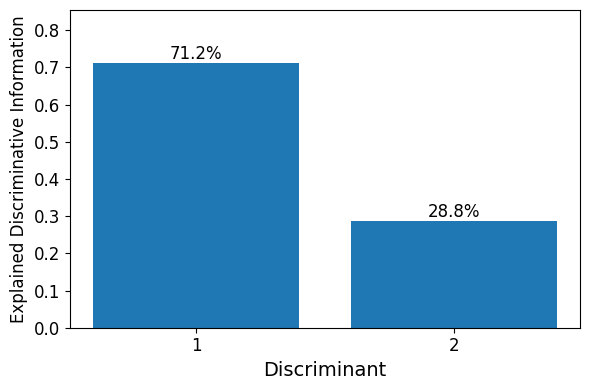

In [27]:
plot_explained_variance(lda.explained_variance_ratio_, style="bar", show_ratios=True)

As mentioned above, we are generally interested in the cumulative explained variance to see how many principal components we need to cross a threshold with respect to the overall explained variance. Using the [`np.cumsum()`](https://numpy.org/doc/stable/reference/generated/numpy.cumsum.html) method of NumPy this is very easy to do.

In [28]:
cumulative_explained_variance = np.cumsum(lda.explained_variance_ratio_)

with np.printoptions(precision=3):
    print(cumulative_explained_variance)

[0.712 1.   ]


And, of course, we can visualize the results using a bar or line plot.

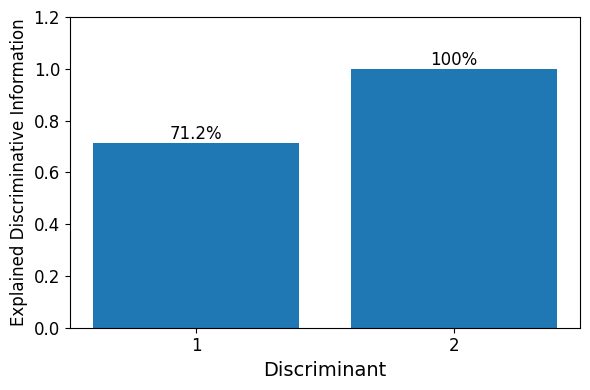

In [29]:
plot_explained_variance(cumulative_explained_variance, style="bar", show_ratios=True)

Based on these numbers and the fact that we generally aim to capture at least $90\%$ of the discriminative information, reducing our $3$-dimensional down to just $1$-dimension would lose to much information &mdash; and we already saw this when we plotted the projected data points. Keep in mind, of course, that practical dataset may have many more classes where a coverage of more than $90\%$ of the discriminative information is achievable with (much) fewer than $C-1$ discriminants. For our example dataset, the plot above with $p=2$ is arguably a bit boring.

**Cross-validated classification performance.** Since LDA is a supervised method, we have a ground-truth in terms of the class labels in the training data to assess the quality of the classifier. As such, The most practical approach is to treat the number of discriminants as a hyperparameter. Train a classifier using the first $p$ discriminants $p=1,\dots,C−1$ and evaluate its performance using cross-validation. The value of $p$ that yields the highest validation accuracy, F1 score, or other relevant metric is selected. This directly optimizes the quantity that ultimately matters: predictive performance. In practice, this is generally considered the most reliable method, because the discriminants that explain the most between-class variance are not always the ones that produce the best predictive performance on unseen data. Eigenvalue-based methods and scree plots are useful heuristics, while cross-validation provides direct evidence of how many discriminants are actually needed for the task.

---

## Discussion

### Limitations & Challenges

The main limitations of LDA stem from its core assumption that the observations in each class are generated from a single (unimodal) multivariate normal distribution with a covariance structure that is shared across all classes. In practice, real-world datasets often violate these assumptions: classes may exhibit skewed distributions, multiple subgroups (multimodality), heavy tails, outliers, or differing covariance patterns. When the true data-generating process deviates substantially from these assumptions, the estimated class distributions and decision boundaries may no longer accurately reflect the underlying class structure, leading to reduced classification performance. Consequently, the effectiveness of LDA depends heavily on how well its distributional assumptions approximate the characteristics of the data.

The figure below shows three, admittedly artificial datasets that clearly violate this core assumption underlying LDA:

* **Bimodal distributions (left plot).** Although each cluster looks like a Gaussian blob, we have the situation where each class is "covered" by two blobs. In this extreme case, the data distribution is such that the overall a mean and the class mean are identical, i.e., $\boldsymbol{\mu} = \boldsymbol{\mu}_{red} = \boldsymbol{\mu}_{blue}$. In general, if a class actually comes from a multimodal distribution, LDA will still attempt to model it using a single multivariate normal distribution. As a result, the estimated class mean will lie somewhere between the two modes, potentially in a region where few or no observations actually occur. The estimated covariance matrix will also be inflated to account for the large spread between the modes. Consequently, the fitted class distribution may be a poor representation of the true data-generating process.

* **Non-Gaussian distribution (middle plot).** If the classes come from a non-Gaussian (non-normal) distribution, LDA's estimate of the class-conditional likelihoods may be inaccurate because the assumed probability model does not match the true data-generating process. Since the posterior probabilities and decision boundaries are derived from these likelihoods, violations of the normality assumption can lead to suboptimal classification performance. The severity of the problem depends on the nature of the deviation from normality. Mild departures, such as moderate skewness or kurtosis, often have little impact and LDA can remain surprisingly effective. However, strongly skewed distributions, heavy-tailed distributions, bounded variables, or distributions with multiple modes can distort the estimated class means and covariance matrices, resulting in posterior probabilities that poorly reflect the true class membership probabilities. 

* **Equal class means (right plot).** Even if all classes perfectly satisfy the Gaussian assumptions of LDA, the method can still perform poorly when the class means are very similar or identical. LDA derives its discriminant directions by maximizing the separation between class means relative to the variation within classes. If the class means are close together, there is little between-class variation to exploit, making it difficult to find directions that effectively distinguish the classes. In the extreme case where the class means are identical, the between-class scatter matrix becomes zero, meaning there is no linear combination of features that separates the classes based on their means. Under LDA's assumptions of a shared covariance matrix, the class-conditional distributions become identical, and the posterior probabilities are determined solely by the class priors. As a result, LDA cannot meaningfully discriminate between the classes and will tend to assign observations to the most probable class according to the prior probabilities. More generally, when class means are only slightly different relative to the within-class variability, the discriminant directions may exist but provide weak separation, resulting in low classification accuracy.

<img src="images/plots/dimreduction/dimreduction-lda-limitations.png" style="margin:auto;width:100%" alt="LDA - Limitations">

In short, the usefulness of LDA depends critically on the extent to which its underlying assumptions are satisfied. LDA assumes that each class can be reasonably modeled by a unimodal multivariate normal distribution, that classes share a common covariance structure, and that meaningful separation exists between class means. While LDA is often robust to moderate deviations from these assumptions, substantial violations (e.g., multimodal class distributions, strong non-normality, heterogeneous covariances, or highly overlapping class means) can reduce the quality of the discriminant directions, posterior probability estimates, and resulting classifications.

For this reason, it is good practice to assess these assumptions during the exploratory data analysis (EDA) phase before applying LDA. Visualizations, summary statistics, and diagnostic analyses can help identify skewed distributions, multimodal structures, outliers, covariance differences, and insufficient class separation. By understanding the characteristics of the data beforehand, you can better judge whether LDA is an appropriate choice, whether data transformations are needed, or whether a more flexible alternative should be considered. Such preliminary checks increase the likelihood that the resulting discriminants and classifications are meaningful and reliable.

### Extensions & Variants

While basic Linear Discriminant Analysis (LDA) is powerful, its strict assumptions &mdash; such as linear decision boundaries, homoscedasticity (equal covariance matrices across all classes), and sensitivity to multicollinearity &mdashl can limit its performance on complex, real-world datasets. To address these limitations, several extensions and variants have been developed. The most common variants can be grouped by the specific problem they solve:

#### Handling Non-Linear Decision Boundaries

* **Quadratic Discriminant Analysis (QDA)**. Basic LDA assumes all classes share the same covariance matrix ($\Sigma_k = \Sigma$). When this assumption is violated, LDA performs poorly. QDA drops the equal covariance assumption, allowing each class to estimate its own covariance matrix $\Sigma_k$. This changes the decision boundary from a straight line (or hyperplane) into a quadratic curve (parabola, ellipse, or hyperbola). The trade-off here is that QDA requires estimating significantly more parameters, making it highly prone to overfitting if the training dataset is small.

* **Kernel Linear Discriminant Analysis (KLDA).** LDA can only find linear combinations of features to separate classes. If the data is inherently nonlinear (e.g., concentric circles), LDA fails. Using the "kernel trick" (similar to Support Vector Machines), KLDA implicitly maps the input features into a higher-dimensional space where the classes become linearly separable, and then performs standard LDA in that new space.

#### Handling High-Dimensional Data ($p > n$)

When the number of features ($p$) exceeds the number of samples ($n$), the within-class covariance matrix becomes singular and cannot be inverted. This is known as the "small sample size problem" or the curse of dimensionality.

* **Regularized / Stripped Discriminant Analysis (RDA).** RDA introduces a shrinkage parameter ($\gamma$) to regularize the covariance matrices, blending the individual class covariance matrices of QDA with the shared matrix of LDA, and further pulling them toward a diagonal matrix (like Naive Bayes). This stabilizes the matrix inversion.

* **Sparse LDA (SLDA).** SLDA applies an $L_1$ penalty (Lasso regularization) to the discriminant coefficients. This forces the coefficients of less important features to be exactly zero. In other words, SLDA inherently performs feature selection, identifying a small subset of the most informative predictors, which significantly improves model interpretability.



#### Handling Complex or Multi-Modal Distributions

* **Mixture Discriminant Analysis (MDA).** LDA assumes that each class follows a single multivariate normal distribution. If a class contains multiple distinct subgroups (e.g., a "Car" class containing sports cars and delivery trucks), a single normal distribution cannot accurately model it. MDA models the distribution of each class as a mixture of multiple Gaussian distributions (a Gaussian Mixture Model) instead of just one.

* **Flexible Discriminant Analysis (FDA).** FDA casts LDA as a multi-response linear regression problem. By replacing standard linear regression with non-parametric regression techniques, such as Multivariate Adaptive Regression Splines (MARS) or polynomial splines, it allows for highly flexible, non-linear decision surfaces.


Because these extensions and variants fundamentally alter the core mathematical framework of basic Linear Discriminant Analysis, they represent nontrivial modifications that cannot be treated as mere parameter tweaks. Adapting LDA to handle non-linear structures, high-dimensional feature spaces, or multi-modal distributions requires replacing its foundational assumptions &mdash; such as the single multivariate normal distribution per class or the shared homoscedastic covariance matrix &mdash; with entirely different mathematical formulations. Consequently, each of these variants shifts the model's behavior so significantly that a comprehensive understanding requires an independent, detailed discussion of their respective geometric interpretations, mathematical derivations, and algorithmic implementations.

---

## Summary

This notebook provided a comprehensive exploration of **Linear Discriminant Analysis (LDA)**, covering both its theoretical foundations and practical implementation. Starting from the probabilistic formulation based on Bayes' Theorem, we derived the LDA classification rule, examined the role of class priors and class-conditional likelihoods, and developed the discriminant functions used for prediction. We then studied the dimensionality reduction perspective of LDA, introducing the concepts of within-class and between-class scatter and showing how the optimal discriminant directions are obtained through a generalized eigenvalue problem.

A key theme throughout the notebook was understanding LDA as a **supervised linear dimensionality reduction technique**. Unlike Principal Component Analysis (PCA), which is unsupervised and seeks directions of maximum overall variance without considering class labels, LDA explicitly incorporates class information and aims to find directions that maximize class separability. This distinction makes LDA particularly valuable for classification tasks, where preserving discriminatory information is often more important than preserving overall variance. We also discussed the practical implications of the theoretical result that LDA can produce at most (C-1) discriminant directions for (C) classes.

Beyond the mathematical derivations, we implemented LDA from scratch in Python to gain a deeper understanding of its inner workings. The implementation walked through each step of the algorithm, including the computation of class means, scatter matrices, eigenvalue decomposition, dimensionality reduction, and classification. The emphasis was intentionally placed on clarity and educational value rather than computational efficiency, allowing each component of the algorithm to be examined and understood in isolation.

Finally, we examined the assumptions underlying LDA and discussed their practical consequences. In particular, we highlighted the assumptions that each class follows a unimodal multivariate normal distribution and that all classes share a common covariance structure. We explored how violations of these assumptions can affect the quality of the resulting discriminants and classifications, emphasizing the importance of exploratory data analysis before applying LDA. While implementing LDA from scratch is highly valuable for learning, production applications should generally rely on well-tested implementations from mature machine learning libraries such as scikit-learn, which provide optimized, numerically stable, and thoroughly validated implementations of the algorithm.